In [852]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

In [853]:
def report(y_true,y_pred):
    report = classification_report(y_true,y_pred)
    conf_matrix = confusion_matrix(y_true,y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix)
    disp.plot()
    print(report)

In [854]:
def model_training(list_of_models,X_train,y_train,X_test,y_test):
    for model in list_of_models:
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        print(f"Model: {model.__class__.__name__}")
        report(y_test,y_pred)


In [855]:
df = pd.read_csv('TCA_Cleaned.csv')

In [856]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
236,237,0,2,"Hold, Mr. Stephen",male,44.0,2,26707,26.0000,S,Mr
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,1,349212,7.8958,S,Mr
467,468,0,1,"Smart, Mr. John Montgomery",male,56.0,1,113792,26.5500,S,Mr
647,648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,1,13213,35.5000,C,Col
675,676,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.0,1,349912,7.7750,S,Mr


In [857]:
df["Age"] = df["Age"].fillna(
    df.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

In [858]:
df['Age'].isnull().sum()

np.int64(0)

In [859]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       2
Title          1
dtype: int64

In [860]:
df.dropna(inplace=True)

In [861]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64

In [862]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
656,657,0,3,"Radeff, Mr. Alexander",male,25.0,1,349223,7.8958,S,Mr
642,643,0,3,"Skoog, Miss. Margit Elizabeth",female,2.0,6,347088,27.9000,S,Miss
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,1,PC 17760,135.6333,C,Miss
255,256,1,3,"Touma, Mrs. Darwis (Hanne Youssef Razi)",female,29.0,3,2650,15.2458,C,Mrs
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,7,347082,31.2750,S,Miss


## Using StandardScaler on age and Fare columns
## OneHotencoding the sex,Title and embarked columns

In [863]:
numerical_features = ['Age', 'Fare']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.531847,2,A/5 21171,-0.499063,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.674103,2,PC 17599,0.790270,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.230360,1,STON/O2. 3101282,-0.485471,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.447987,2,113803,0.424143,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,0.447987,1,373450,-0.482955,S,Mr


In [864]:
df['Title'].value_counts()

Title
Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Don           1
Mme           1
Ms            1
Sir           1
Lady          1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [865]:
categorical_features = ['Sex', 'Embarked', 'Title']
Sex = {'male':0,"female":1}
embarked = {'S':0,'C':1,'Q':2}
title = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Other':4}
def map_values(value):
    value['Sex'] = Sex[value['Sex']]
    value['Embarked'] = embarked[value['Embarked']]
    try: 
        value['Title'] = title[value['Title']]
    except KeyError:
        value['Title'] = 4
    return value
df[['Sex','Embarked','Title']] = df[['Sex','Embarked','Title']].apply(map_values, axis=1)

In [866]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.531847,2,A/5 21171,-0.499063,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.674103,2,PC 17599,0.790270,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.230360,1,STON/O2. 3101282,-0.485471,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.447987,2,113803,0.424143,0,2
4,5,0,3,"Allen, Mr. William Henry",0,0.447987,1,373450,-0.482955,0,0


In [867]:
xgbModel = XGBClassifier()
svmModel = SVC(kernel='linear',probability=True)
list_of_models = [xgbModel,svmModel]
x = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.15,random_state=42)

In [868]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((754, 7), (754,), (134, 7), (134,))

In [869]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'FamSize', 'Fare', 'Embarked', 'Title'], dtype='object')

Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.89      0.90      0.90        90
           1       0.79      0.77      0.78        44

    accuracy                           0.86       134
   macro avg       0.84      0.84      0.84       134
weighted avg       0.86      0.86      0.86       134

Model: SVC
              precision    recall  f1-score   support

           0       0.90      0.80      0.85        90
           1       0.67      0.82      0.73        44

    accuracy                           0.81       134
   macro avg       0.78      0.81      0.79       134
weighted avg       0.82      0.81      0.81       134



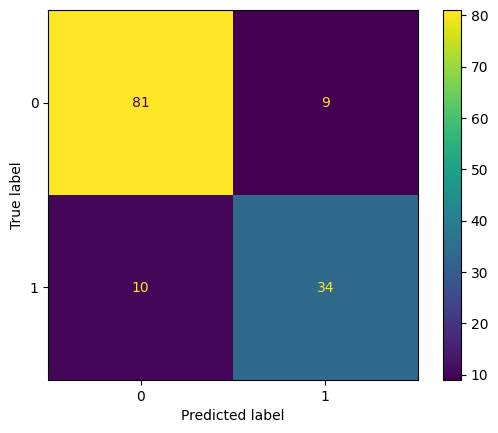

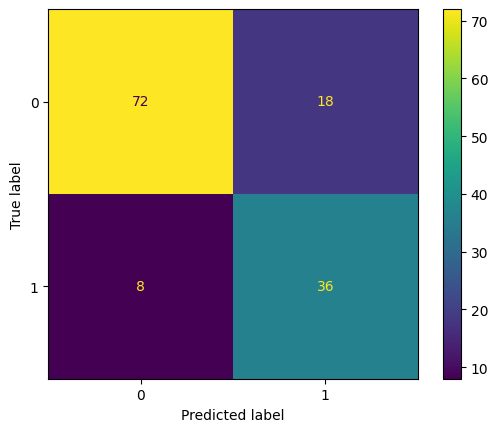

In [870]:
model_training(list_of_models,X_train,y_train,X_test,y_test)

In [871]:
xgbFI = xgbModel.feature_importances_
svmFI = svmModel.coef_[0]

In [872]:
columns = X_train.columns

Text(0.5, 1.0, 'SVM Feature Importance')

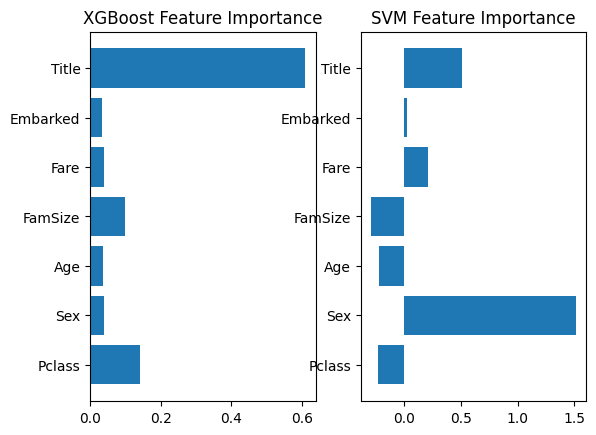

In [873]:
ax = plt.subplot(1,2,1)
ax.barh(columns,xgbFI)
ax.set_title("XGBoost Feature Importance")
ax = plt.subplot(1,2,2)
ax.barh(columns,svmFI)
ax.set_title("SVM Feature Importance")

              precision    recall  f1-score   support

           0       0.89      0.90      0.90        90
           1       0.79      0.77      0.78        44

    accuracy                           0.86       134
   macro avg       0.84      0.84      0.84       134
weighted avg       0.86      0.86      0.86       134



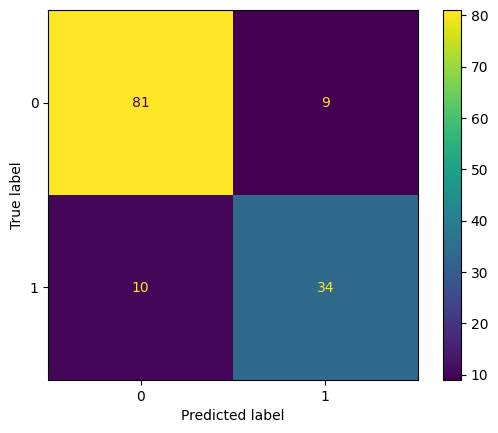

In [874]:
XgbClassifier = XGBClassifier()
XgbClassifier.fit(X_train,y_train)
y_pred = XgbClassifier.predict(X_test)
report(y_test,y_pred)

In [875]:
test_data = pd.read_csv('test.csv')

In [876]:
test_data.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
332,1224,3,"Thomas, Mr. Tannous",male,NaN,0,0,2684,7.2250,NaN,C
209,1101,3,"Delalic, Mr. Redjo",male,25.0,0,0,349250,7.8958,NaN,S
204,1096,2,"Andrew, Mr. Frank Thomas",male,25.0,0,0,C.A. 34050,10.5000,NaN,S
266,1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0000,NaN,S
275,1167,2,"Bryhl, Miss. Dagmar Jenny Ingeborg",female,20.0,1,0,236853,26.0000,NaN,S


In [ ]:
test_data[numerical_features] = scaler.transform(test_data[numerical_features])
test_data[['Sex','Embarked','Title']] = test_data[['Sex','Embarked','Title']].apply(map_values, axis=1)

In [ ]:
XgbClassifier